<a href="https://colab.research.google.com/github/youssefokeil/AI-Based-Market-Property-Analysis/blob/main/DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from pathlib import Path 
import warnings
warnings.filterwarnings('ignore')

In [68]:
# Palette constants
ACCENT  = '#534AB7'   # indigo  — primary bars / main data series
ACCENT2 = '#0F6E56'   # teal    — secondary series / positive signal
WARM    = '#D85A30'   # coral   — high values / alerts / negative delta
COLD    = '#185FA5'   # blue    — informational / cold indicators
GOLD    = '#BA7517'   # amber   — medians, reference lines, highlights
NEUTRAL = '#5F5E5A'   # slate   — annotations, minor labels, grid

# Light fills (use for bar transparency or box-plot patches)
ACCENT_LIGHT  = '#EEEDFE'   # indigo 50
ACCENT2_LIGHT = '#E1F5EE'   # teal 50
WARM_LIGHT    = '#FAECE7'   # coral 50
COLD_LIGHT    = '#E6F1FB'   # blue 50
GOLD_LIGHT    = '#FAEEDA'   # amber 50

# Ordered palette list for multi-series charts (cycle through these)
PALETTE = [ACCENT, ACCENT2, WARM, COLD, GOLD, NEUTRAL]

# rcParams
plt.rcParams.update({
    # Backgrounds
    'figure.facecolor'  : '#FFFFFF',   # pure white figure background
    'axes.facecolor'    : '#F8F8F6',   # very light warm-gray plot area
    'savefig.facecolor' : '#FFFFFF',

    # Frame / spines
    'axes.edgecolor'    : '#D3D1C7',   # gray-200, subtle border
    'axes.linewidth'    : 0.8,

    # Text
    'axes.labelcolor'   : '#2C2C2A',   # near-black for axis labels
    'text.color'        : '#2C2C2A',
    'xtick.color'       : '#5F5E5A',   # slate for tick labels
    'ytick.color'       : '#5F5E5A',

    # Grid
    'axes.grid'         : True,
    'grid.color'        : '#D3D1C7',   # gray-200 — readable but unobtrusive
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'grid.alpha'        : 0.8,

    # Spines — keep only left + bottom for a clean look
    'axes.spines.top'   : False,
    'axes.spines.right' : False,

    # Ticks
    'xtick.major.size'  : 0,           # no tick marks (grid carries the job)
    'ytick.major.size'  : 0,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,

    # Titles & labels
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'semibold',
    'axes.titlecolor'   : '#2C2C2A',
    'axes.labelsize'    : 11,

    # Legend
    'legend.framealpha' : 0.95,
    'legend.edgecolor'  : '#D3D1C7',
    'legend.fontsize'   : 9.5,

    # Lines & markers
    'lines.linewidth'   : 2.0,
    'patch.linewidth'   : 0.5,

    # Font
    'font.family'       : 'DejaVu Sans',

    # Figure sizing
    'figure.dpi'        : 120,
    'figure.autolayout' : True,
})

# Register the palette as the default color cycle
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=PALETTE)

In [69]:
import os
os.path.exists('./Cleaning Data/final_unified_property_data.csv')

True

In [70]:
# Data Loading & Basic Sanity Check
df = pd.read_csv('./Cleaning Data/final_unified_property_data.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape           : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage    : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print("\nColumn dtypes:")
print(df.dtypes)

print("\nMissing values (%):")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(2))

print("\nBasic statistics (numeric):")
print(df.describe().round(2))  # display formatted descriptive summary

DATASET OVERVIEW
Shape           : 25,165 rows × 20 columns
Memory usage    : 9.28 MB

Column dtypes:
source                           str
unified_price                  int64
unified_area                   int64
price_per_sqm                float64
unified_rooms                  int64
unified_bathrooms              int64
unified_property_type            str
district                         str
unified_location                 str
gross_rental_yield_pct       float64
estimated_annual_rent        float64
estimated_roi_percent        float64
estimated_monthly_rent       float64
has_elevator                   int64
has_security                   int64
has_balcony                    int64
has_pool                       int64
has_garden                     int64
has_parking                    int64
median_price_per_district    float64
dtype: object

Missing values (%):
Series([], dtype: float64)

Basic statistics (numeric):
       unified_price  unified_area  price_per_sqm  unified_rooms  \

In [71]:
# DESCRIPTIVE STATISTICS: FAIR MARKET VALUE PER DISTRICT
# Goal: Calculate average, median, and price range per district so buyers/sellers can benchmark a listing against its local market.
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS BY DISTRICT")
print("=" * 60)

# Aggregate key metrics per district
district_stats = (
    df.groupby('district')
    .agg(
        count           = ('unified_price',   'count'),
        mean_price      = ('unified_price',   'mean'),
        median_price    = ('unified_price',   'median'),
        std_price       = ('unified_price',   'std'),
        min_price       = ('unified_price',   'min'),
        max_price       = ('unified_price',   'max'),
        mean_ppsm       = ('price_per_sqm',   'mean'),   # price per sq-m
        median_ppsm     = ('price_per_sqm',   'median'),
        mean_area       = ('unified_area',    'mean'),
        mean_roi        = ('estimated_roi_percent', 'mean'),
        mean_yield      = ('gross_rental_yield_pct','mean'),
    )
    .reset_index()
)

# Price range = max − min; CV = coefficient of variation (spread relative to mean)
district_stats['price_range'] = district_stats['max_price'] - district_stats['min_price']
district_stats['cv_price']    = district_stats['std_price']  / district_stats['mean_price'] * 100

# Sort by median price descending for easy reading
district_stats = district_stats.sort_values('median_price', ascending=False)
print(district_stats[['district','count','mean_price','median_price','price_range','mean_ppsm','mean_roi']].to_string(index=False)) # ppsm: price per squared meter


DESCRIPTIVE STATISTICS BY DISTRICT
        district  count   mean_price  median_price  price_range    mean_ppsm  mean_roi
        Mokattam     56 2.984360e+07    18250000.0    164534000 97947.324277       6.0
         Zamalek     20 2.210967e+07    14125000.0     68950000 97992.499152       5.5
       New Cairo   2182 1.733773e+07    10500000.0    199900000 64927.708815       7.5
     Garden City      3 9.153333e+06     8260000.0     12800000 41566.870973       5.0
      Heliopolis    111 1.064201e+07     8000000.0     86640000 51869.486380       7.0
        Madinaty    140 1.538481e+07     7750000.0    119600000 68565.942848       7.5
    Shorouk City    131 8.237007e+06     6500000.0     39610000 37673.381271       6.8
  Mostakbal City    303 7.585973e+06     6200000.0     31800000 39523.566513       7.0
       Noor City     37 7.645363e+06     5500000.0     19010000 54070.824424       7.0
        El Nozha     50 5.294662e+06     5331600.0     16523000 42499.856583       6.8
       

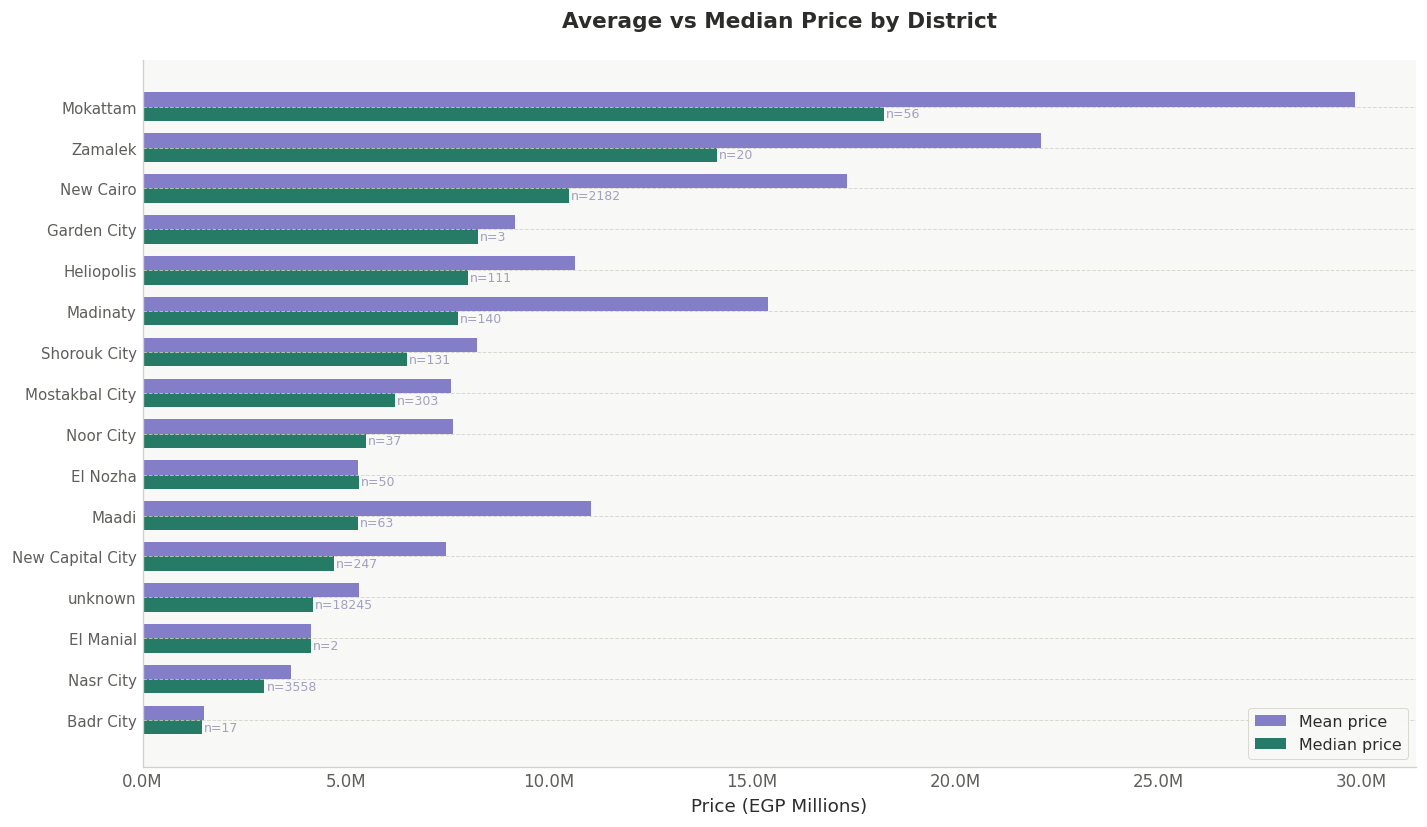

→ Saved: chart_1_BarChart_price_by_district.png


In [72]:
# CHART 1: Average & Median Price by District (bar chart)
top_districts = (district_stats
                 .nlargest(16, 'count')
                 .sort_values('median_price', ascending=True))

fig, ax = plt.subplots(figsize=(12, 7))
y_pos   = np.arange(len(top_districts))
h_bar   = 0.35

# Mean bars (lighter)
ax.barh(y_pos + h_bar/2, top_districts['mean_price']   / 1e6,
        h_bar, color=ACCENT,  alpha=0.7, label='Mean price')
# Median bars (solid)
ax.barh(y_pos - h_bar/2, top_districts['median_price'] / 1e6,
        h_bar, color=ACCENT2, alpha=0.9, label='Median price')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_districts['district'], fontsize=9)
ax.set_xlabel('Price (EGP Millions)')
ax.set_title(f'Average vs Median Price by District\n')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.grid(axis='x')

# Annotate with listing counts
for i, (_, row) in enumerate(top_districts.iterrows()):
    ax.text(row['median_price'] / 1e6 + 0.05, i - h_bar/2,
            f"n={int(row['count'])}", va='center', fontsize=7.5,
            color='#a0a0c0')

plt.tight_layout()
plt.savefig('./Plots/chart_1_BarChart_price_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_1_BarChart_price_by_district.png")

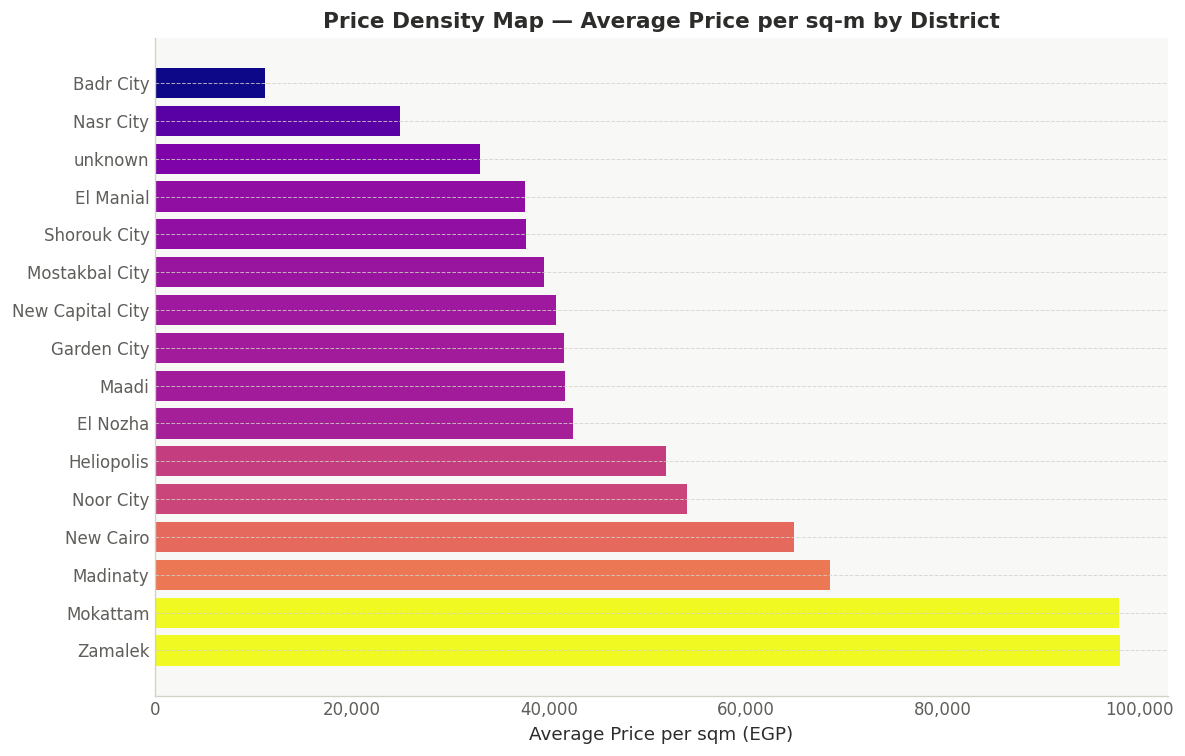

→ Saved: chart_2_PriceDenistyMap_ppsm_by_district.png


In [73]:
# CHART 2: Price-per-sqm Heatmap across Districts
# Reveals where buyers pay a premium per unit area (useful for density analysis, which calculate concentration of a feature across a map)
ppsm_sorted = district_stats.dropna(subset=['mean_ppsm']).sort_values('mean_ppsm',ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(ppsm_sorted) * 0.4)))
bars = ax.barh(ppsm_sorted['district'], ppsm_sorted['mean_ppsm'],
               color=plt.cm.plasma(
                   (ppsm_sorted['mean_ppsm'] - ppsm_sorted['mean_ppsm'].min())
                   / (ppsm_sorted['mean_ppsm'].max() - ppsm_sorted['mean_ppsm'].min())
               ))
ax.set_xlabel('Average Price per sqm (EGP)')
ax.set_title('Price Density Map — Average Price per sq-m by District')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('./Plots/chart_2_PriceDenistyMap_ppsm_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_2_PriceDenistyMap_ppsm_by_district.png")

In [74]:
# UNDERVALUED AREA DETECTION
# An area is "undervalued" if its price_per_sqm is significantly below the national median(cheaper than typical) but its ROI / rental yield are at or above average(better returns than typical)
# This pinpoints investor opportunities hidden by the market.

print("\n" + "=" * 60)
print("UNDERVALUED AREA DETECTION")
print("=" * 60)

national_median_ppsm  = df['price_per_sqm'].median()  # typical price
national_mean_roi     = df['estimated_roi_percent'].mean()  # average roi
national_mean_yield   = df['gross_rental_yield_pct'].mean() # average rental yield

print(f"National median price/sqm : {national_median_ppsm:,.0f} EGP")
print(f"National mean ROI         : {national_mean_roi:.2f}%")
print(f"National mean yield       : {national_mean_yield:.2f}%")

# Flag undervalued: below-median price AND above-average ROI
undervalued = district_stats[
    (district_stats['median_ppsm'] < national_median_ppsm) &  # cheaper than median
    (district_stats['mean_roi']    > national_mean_roi)     # returns better than average
].copy()
# Show how much cheaper the district is compared to the national median
undervalued['ppsm_discount_pct'] = (
    (national_median_ppsm - undervalued['median_ppsm']) / national_median_ppsm * 100
)

print(f"\nUndervalued districts found: {len(undervalued)}")
print(undervalued[['district','median_ppsm','ppsm_discount_pct','mean_roi','count']].sort_values('ppsm_discount_pct', ascending=False).to_string(index=False))


UNDERVALUED AREA DETECTION
National median price/sqm : 27,500 EGP
National mean ROI         : 6.89%
National mean yield       : 6.89%

Undervalued districts found: 1
 district  median_ppsm  ppsm_discount_pct  mean_roi  count
Nasr City 22727.272727          17.355372       8.5   3558


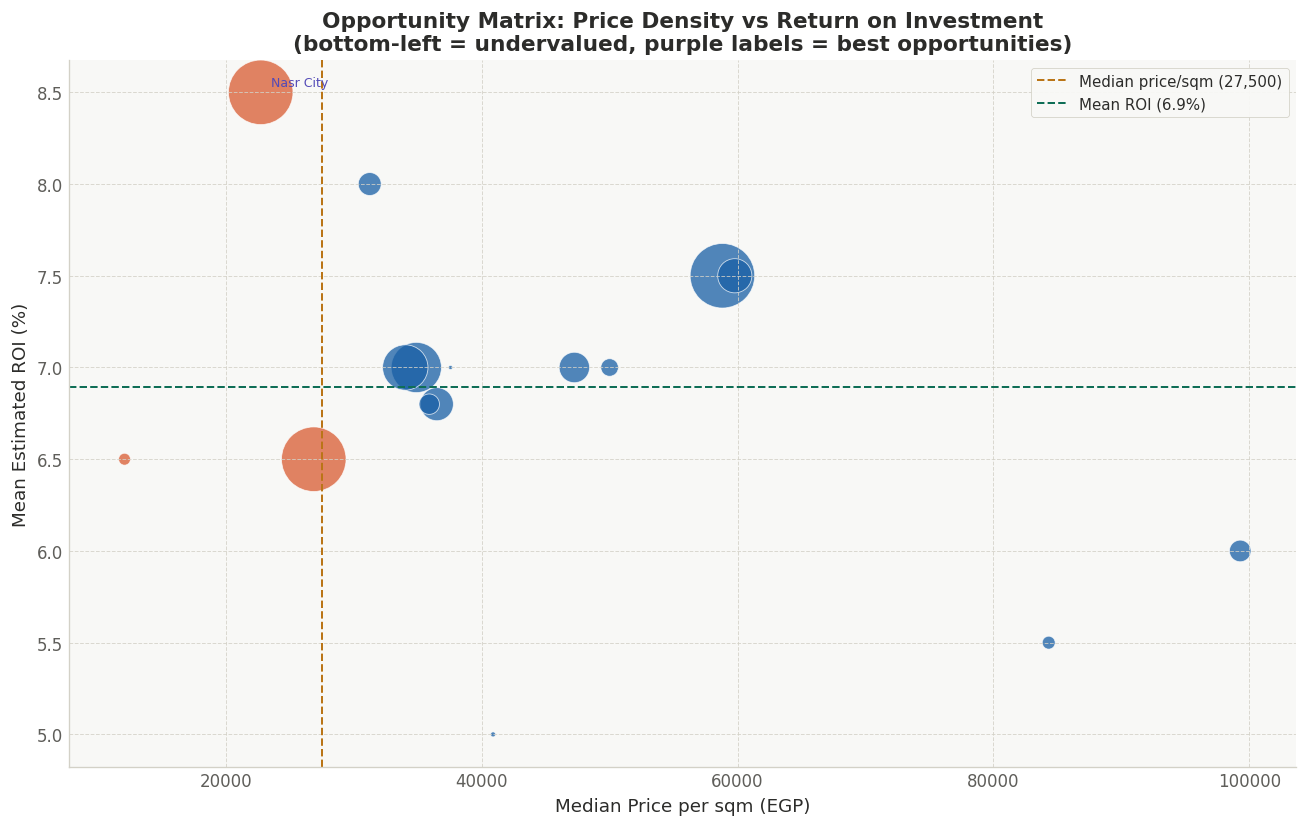

→ Saved: chart_3_UndervaluedBubbleChart_opportunity_matrix.png


In [75]:
# CHART 3: Bubble chart — price/sqm vs ROI, bubble size = listing count
# Bubble chart (opportunity matrix) that visualizes the trade-off between price and returns across districts - essentially a map for finding investment opportunities.
fig, ax = plt.subplots(figsize=(11, 7))

colors = [WARM if r < national_median_ppsm else COLD
          for r in district_stats['median_ppsm']]

scatter = ax.scatter(
    district_stats['median_ppsm'],
    district_stats['mean_roi'],
    s      = district_stats['count'].clip(upper=500) * 3,
    c      = colors,
    alpha  = 0.75,
    edgecolors = 'white',
    linewidths = 0.5,
)

# Reference lines
ax.axvline(national_median_ppsm, color=GOLD, lw=1.2, ls='--',
           label=f'Median price/sqm ({national_median_ppsm:,.0f})')   # Vertical line at median price
ax.axhline(national_mean_roi,    color=ACCENT2, lw=1.2, ls='--',
           label=f'Mean ROI ({national_mean_roi:.1f}%)')         # Horizontal line at mean ROI

# Label undervalued (bottom-left quadrant = low price + higher ROI → highlight)
for _, row in district_stats.iterrows():
    if (row['median_ppsm'] < national_median_ppsm and
            row['mean_roi'] > national_mean_roi):
        ax.annotate(row['district'],  # annotate only the undervalued district, in order not to overwhelme the user
                    xy=(row['median_ppsm'], row['mean_roi']),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=7.5, color=ACCENT)

ax.set_xlabel('Median Price per sqm (EGP)')
ax.set_ylabel('Mean Estimated ROI (%)')
ax.set_title('Opportunity Matrix: Price Density vs Return on Investment\n'
             '(bottom-left = undervalued, purple labels = best opportunities)')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig('./Plots/chart_3_UndervaluedBubbleChart_opportunity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_3_UndervaluedBubbleChart_opportunity_matrix.png")

In [76]:
# FEATURE CORRELATION: HOW MUCH DO AMENITIES IMPACT PRICE?
# Method: Compare median price of listings WITH vs WITHOUT each binary amenity, using Mann-Whitney U test (non-parametric, robust to skewed prices).
# Box plots visualise the distribution spread per amenity group.

print("\n" + "=" * 60)
print("AMENITY IMPACT ON PRICE (BOX PLOTS + STATISTICS)")
print("=" * 60)

BINARY_FEATURES = [
    'has_elevator', 'has_security', 'has_balcony',
    'has_pool',     'has_garden',   'has_parking'
]

# Remove any feature not in the dataframe
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in df.columns]

results = []
# For Each Amenity, Split Properties into Two Groups
for feat in BINARY_FEATURES:
    group_yes = df.loc[df[feat] == 1, 'unified_price'].dropna()
    group_no  = df.loc[df[feat] == 0, 'unified_price'].dropna()

    if len(group_yes) < 5 or len(group_no) < 5:
        continue   # skip if too few samples for meaningful stats

    med_yes   = group_yes.median()
    med_no    = group_no.median()
    premium   = (med_yes - med_no) / med_no * 100   # premium as %
    # Statistical Significance Test
    # p < 0.05 → Significant difference (amenity truly impacts price, not random chance)
    # p ≥ 0.05 → No statistically significant effect
    stat, p   = stats.mannwhitneyu(group_yes, group_no, alternative='two-sided')

    results.append({
        'feature'      : feat.replace('has_', '').title(),
        'count_yes'    : len(group_yes),
        'count_no'     : len(group_no),
        'median_yes'   : med_yes,
        'median_no'    : med_no,
        'premium_pct'  : premium,
        'p_value'      : p,
        'significant'  : 'Y' if p < 0.05 else 'N',
    })

results_df = pd.DataFrame(results).sort_values('premium_pct', ascending=False)
print(results_df[['feature','median_yes','median_no','premium_pct','p_value','significant']].to_string(index=False))


AMENITY IMPACT ON PRICE (BOX PLOTS + STATISTICS)
 feature  median_yes  median_no  premium_pct       p_value significant
Elevator   6238325.0  4200000.0    48.531548  9.339250e-84           Y
 Balcony   4000000.0  4500000.0   -11.111111  3.596921e-04           Y
Security   3910000.0  4500000.0   -13.111111  2.430461e-06           Y
 Parking   2712500.0  4560000.0   -40.515351  3.546561e-86           Y
  Garden   2600000.0  4450000.0   -41.573034  5.048670e-18           Y
    Pool   2500000.0  4650000.0   -46.236559 2.144532e-141           Y


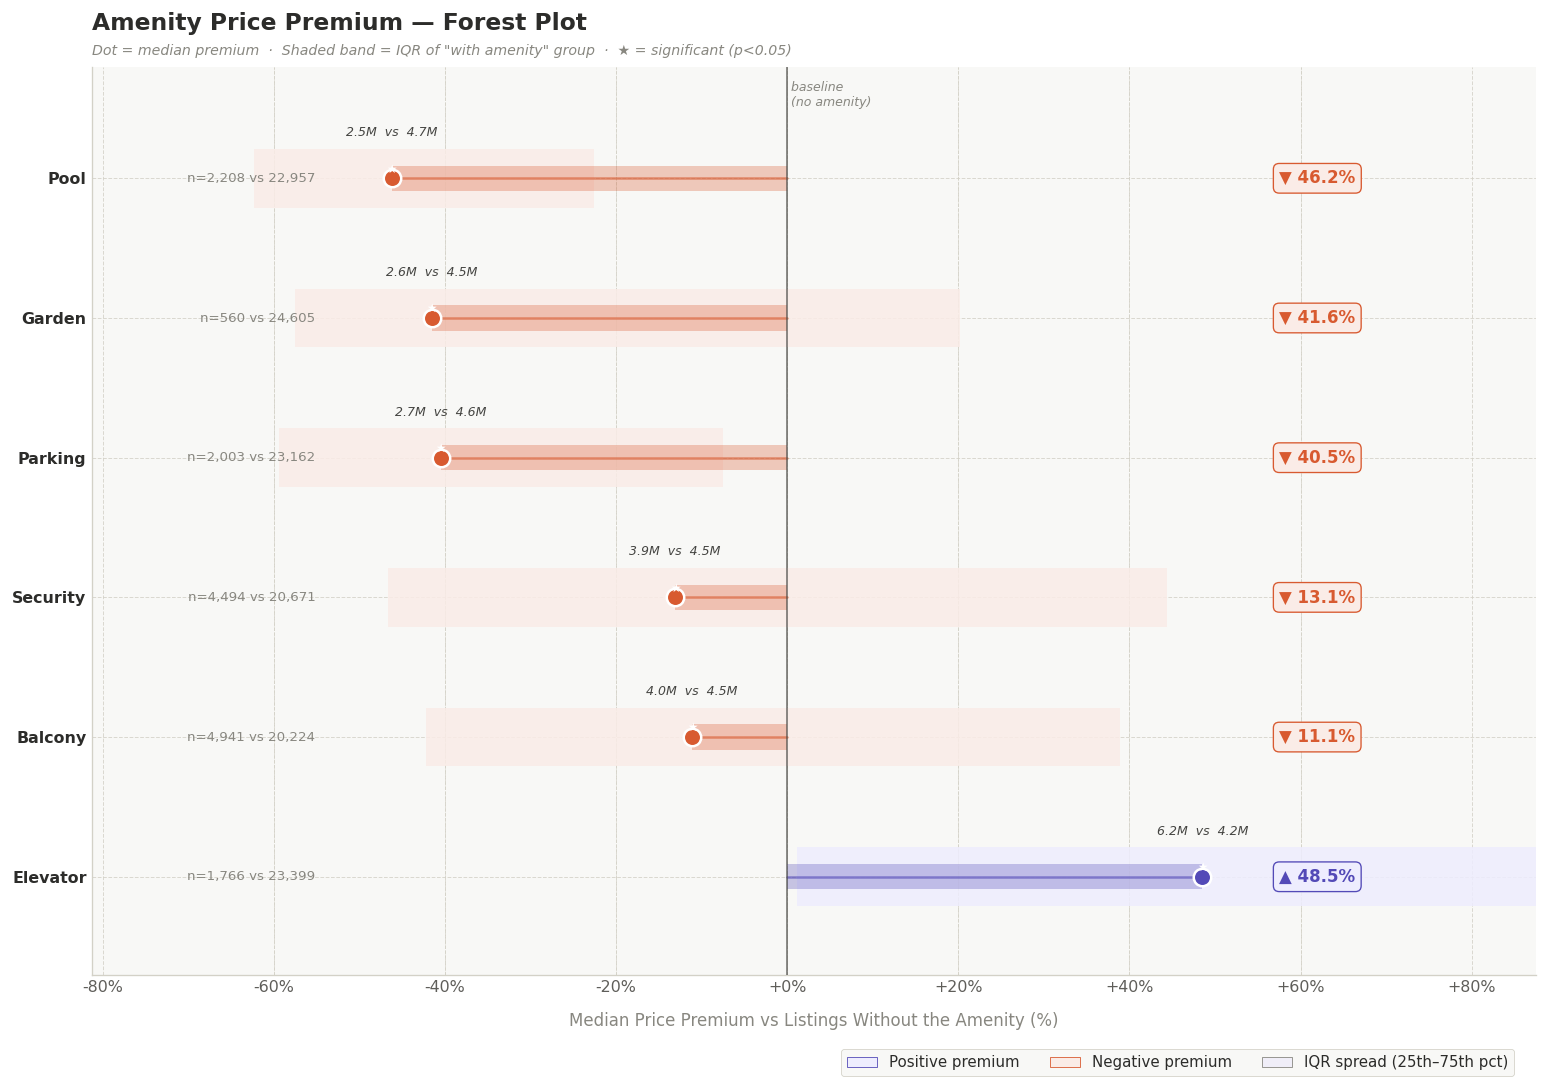

→ Saved: chart_4_ForestPlot_amenity_price_plot.png


In [77]:
# CHART 4 — FOREST / DIVERGING DOT PLOT  (amenity price premium)
# Reads left-to-right: bar length = effect size, color = direction, dot = point estimate, IQR band = spread, badge = % premium.
# Palette
C_POS   = '#534AB7'   # indigo  — positive premium
C_NEG   = '#D85A30'   # coral   — negative premium
C_POS_L = '#EEEDFE'
C_NEG_L = '#FAECE7'
GOLD    = '#BA7517'
NEUTRAL = '#888780'
BORDER  = '#D3D1C7'
BG      = '#FFFFFF'
PLOT_BG = '#F8F8F6'

BINARY_FEATURES = [f for f in [
    'has_elevator','has_security','has_balcony',
    'has_pool','has_garden','has_parking'
] if f in df.columns]

# Compute stats
rows = []
for feat in BINARY_FEATURES:
    sub   = df[[feat, 'unified_price']].dropna()
    g_w   = sub.loc[sub[feat]==1, 'unified_price'] / 1e6
    g_wo  = sub.loc[sub[feat]==0, 'unified_price'] / 1e6
    label = feat.replace('has_','').title()

    med_w  = g_w.median();   q1_w  = g_w.quantile(0.25); q3_w  = g_w.quantile(0.75)
    med_wo = g_wo.median();  q1_wo = g_wo.quantile(0.25); q3_wo = g_wo.quantile(0.75)

    premium = (med_w - med_wo) / med_wo * 100
    _, pval = stats.mannwhitneyu(g_w, g_wo, alternative='two-sided')

    rows.append(dict(
        label=label, premium=premium, pval=pval,
        med_w=med_w,  q1_w=q1_w,  q3_w=q3_w,  n_w=len(g_w),
        med_wo=med_wo, q1_wo=q1_wo, q3_wo=q3_wo, n_wo=len(g_wo),
    ))

# Sort by premium so the chart reads as a ranking
rows = sorted(rows, key=lambda x: x['premium'], reverse=True)
n    = len(rows)
labels  = [r['label']  for r in rows]
prems   = [r['premium'] for r in rows]
pvals   = [r['pval']   for r in rows]

# Figure
fig, ax = plt.subplots(figsize=(13, 1.1 * n + 2.5), facecolor=BG)
ax.set_facecolor(PLOT_BG)

y_pos = np.arange(n)

for i, row in enumerate(rows):
    pct   = row['premium']
    sig   = row['pval'] < 0.05
    color = C_POS if pct >= 0 else C_NEG
    light = C_POS_L if pct >= 0 else C_NEG_L

    # Shaded IQR band (shows spread of "with" group)
    # Convert IQR to premium-equivalent for visual consistency
    iqr_lo = (row['q1_w'] - row['med_wo']) / row['med_wo'] * 100
    iqr_hi = (row['q3_w'] - row['med_wo']) / row['med_wo'] * 100
    ax.barh(i, iqr_hi - iqr_lo, left=iqr_lo, height=0.42,
            color=light, alpha=0.85, linewidth=0, zorder=2)

    # Horizontal bar (premium magnitude)
    ax.barh(i, pct, height=0.18,
            color=color, alpha=0.30, linewidth=0, zorder=3)

    # Centre line (connects dot to zero)
    ax.plot([0, pct], [i, i], color=color, lw=1.5, alpha=0.6,
            solid_capstyle='round', zorder=3)

    # Point estimate dot
    ax.scatter(pct, i, s=110, color=color, zorder=5,
               edgecolors='white', linewidths=1.5)

    # Significance star on the dot
    if sig:
        ax.text(pct, i + 0.02, '★', ha='center', va='bottom',
                fontsize=7, color='white', zorder=6, fontweight='bold')

    # Premium badge (right side)
    sign = '▲' if pct >= 0 else '▼'
    badge_x = max(prems) * 1.02 + 8
    ax.text(badge_x, i, f'{sign} {abs(pct):.1f}%',
            va='center', ha='left', fontsize=10, fontweight='semibold',
            color=color,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=light,
                      edgecolor=color, linewidth=0.8))

    # Sample size annotation (left side)
    ax.text(min(prems) * 1.02 - 8, i,
            f'n={row["n_w"]:,} vs {row["n_wo"]:,}',
            va='center', ha='right', fontsize=8, color=NEUTRAL)

    # Median price labels above bar
    ax.text(pct, i + 0.28,
            f'{row["med_w"]:.1f}M  vs  {row["med_wo"]:.1f}M',
            va='bottom', ha='center', fontsize=7.5, color='#444441',
            style='italic')

# Zero reference line
ax.axvline(0, color='#444441', lw=1.2, zorder=4, alpha=0.6)
ax.text(0, n - 0.3, ' baseline\n (no amenity)',
        va='top', ha='left', fontsize=7.5, color=NEUTRAL, style='italic')

# Axes formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11, fontweight='semibold', color='#2C2C2A')
ax.set_xlabel('Median Price Premium vs Listings Without the Amenity (%)',
              fontsize=10, color=NEUTRAL, labelpad=10)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))

# Add light vertical grid lines at key percentages
for xv in np.arange(-60, 80, 20):
    ax.axvline(xv, color=BORDER, lw=0.5, ls='--', alpha=0.8, zorder=1)

ax.set_ylim(-0.7, n - 0.2)
pad = max(abs(p) for p in prems) * 0.35
ax.set_xlim(min(prems) - pad - 18, max(prems) + pad + 22)

for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(BORDER)
ax.tick_params(length=0, labelsize=9.5)
ax.set_axisbelow(True)

# Title
ax.set_title('Amenity Price Premium — Forest Plot\n',
             fontsize=14, fontweight='semibold', color='#2C2C2A', loc='left')
ax.text(0, 1.01,
        'Dot = median premium  ·  Shaded band = IQR of "with amenity" group  '
        '·  ★ = significant (p<0.05)',
        transform=ax.transAxes, fontsize=8.5,
        color=NEUTRAL, style='italic', va='bottom')

# Legend
legend_items = [
    mpatches.Patch(facecolor=C_POS_L, edgecolor=C_POS, label='Positive premium'),
    mpatches.Patch(facecolor=C_NEG_L, edgecolor=C_NEG, label='Negative premium'),
    mpatches.Patch(facecolor='#F0EEF8', edgecolor='#888780',
                   label='IQR spread (25th–75th pct)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9,
          framealpha=0.95, edgecolor=BORDER, ncol=3,
          bbox_to_anchor=(0.99, -0.12))

plt.tight_layout()
plt.savefig('./Plots/chart_4_ForestPlot_amenity_price_plot.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("→ Saved: chart_4_ForestPlot_amenity_price_plot.png")

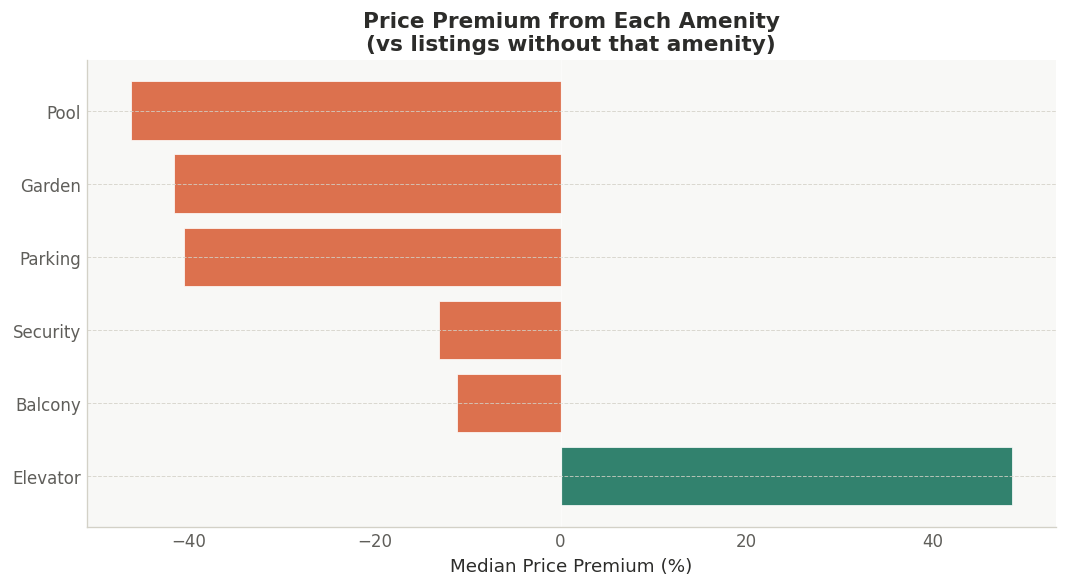

→ Saved: chart_5_PremiumBarChart_amenity_premium_rank.png


In [78]:
# CHART 5: Premium bar chart — amenity price lift ranked(Rank amenities by how much they increase property prices, making it easy to see which features are worth paying for.)
fig, ax = plt.subplots(figsize=(9, 5))
colors  = [ACCENT2 if p >= 0 else WARM for p in results_df['premium_pct']]
bars    = ax.barh(results_df['feature'], results_df['premium_pct'],
                  color=colors, edgecolor='white', lw=0.5, alpha=0.85)
ax.axvline(0, color='white', lw=0.8, alpha=0.5)
ax.set_xlabel('Median Price Premium (%)')
ax.set_title('Price Premium from Each Amenity\n(vs listings without that amenity)')

# Mark statistical significance with a star
for bar, row in zip(bars, results_df.itertuples()):
    x_pos = bar.get_width() + (0.5 if bar.get_width() >= 0 else -0.5)
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f" ★" if row.significant == '✓' else '',
            va='center', color=GOLD, fontsize=11)

ax.grid(axis='x'); plt.tight_layout()
plt.savefig('./Plots/chart_5_PremiumBarChart_amenity_premium_rank.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_5_PremiumBarChart_amenity_premium_rank.png")

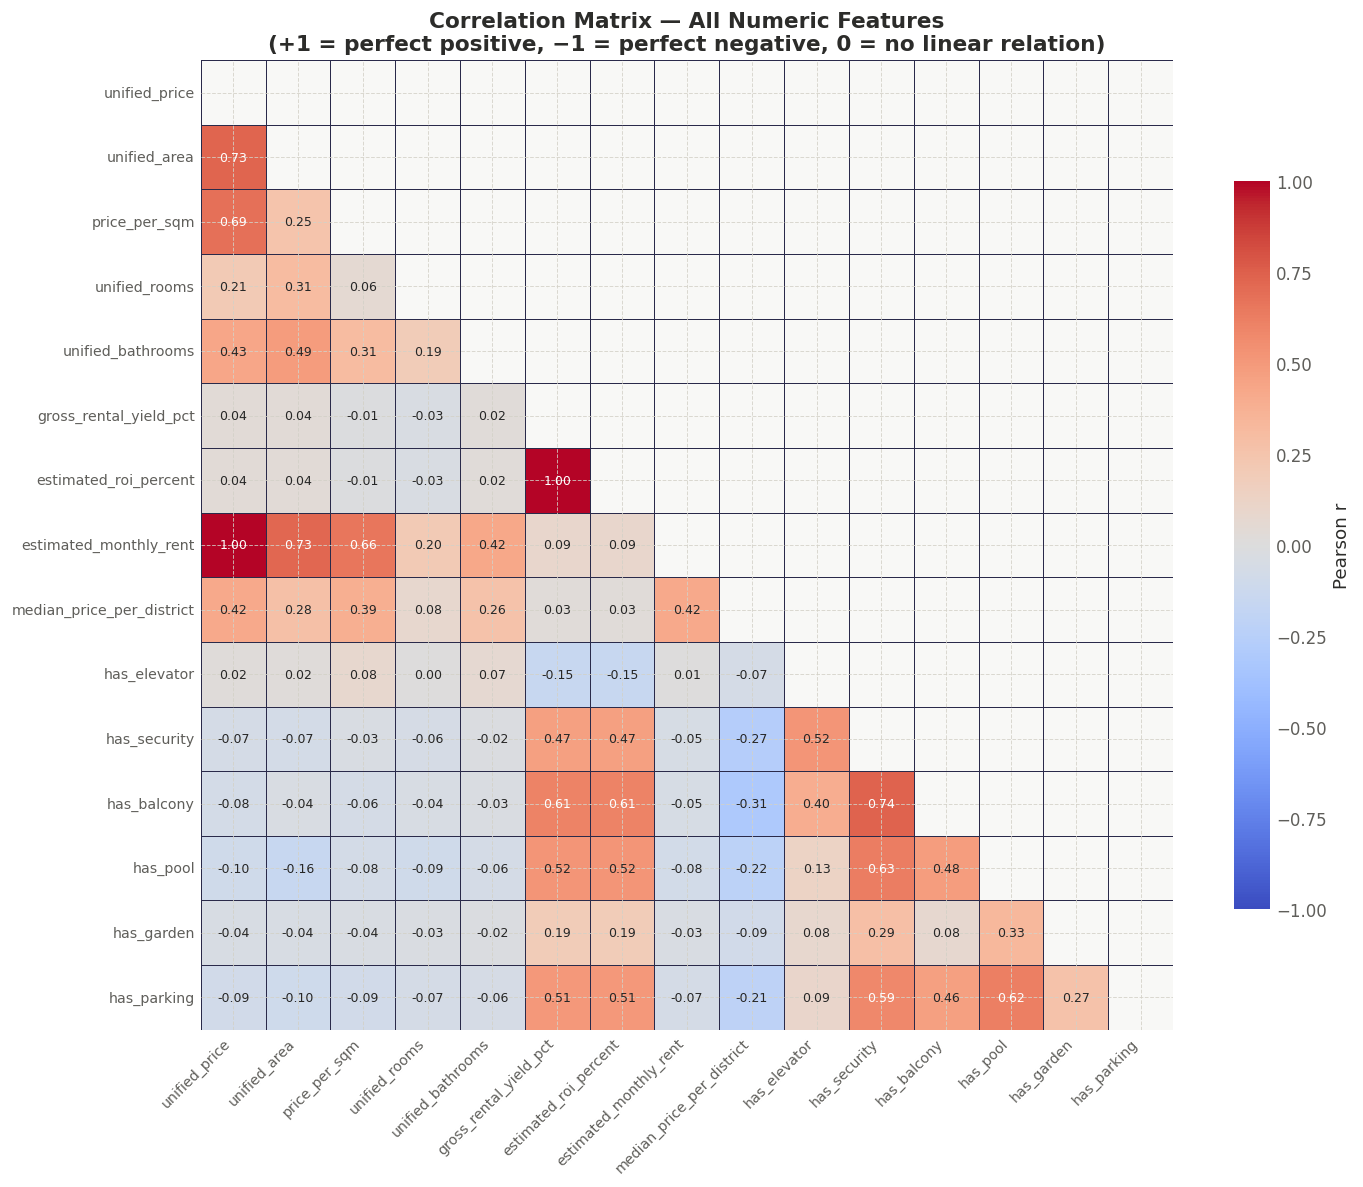

→ Saved: chart_6_CorrelationHeatMap_correlation_matrix.png

Top features correlated with PRICE:
estimated_monthly_rent       0.996
unified_area                 0.727
price_per_sqm                0.686
unified_bathrooms            0.431
median_price_per_district    0.415
unified_rooms                0.207
has_pool                    -0.100
has_parking                 -0.089
has_balcony                 -0.077
has_security                -0.068
has_garden                  -0.040
gross_rental_yield_pct       0.037
estimated_roi_percent        0.037
has_elevator                 0.021


In [79]:
# Chart 6: CORRELATION HEATMAP (NUMERIC FEATURES)
# Shows pairwise Pearson correlations so the team can quickly see which numeric features co-vary strongly — useful for feature engineering & multicollinearity checks.

numeric_cols = [
    'unified_price', 'unified_area', 'price_per_sqm',
    'unified_rooms', 'unified_bathrooms',
    'gross_rental_yield_pct', 'estimated_roi_percent',
    'estimated_monthly_rent', 'median_price_per_district',
] + BINARY_FEATURES

# Keep only columns that actually exist
numeric_cols = [c for c in numeric_cols if c in df.columns]
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    linewidths=0.4, linecolor='#2a2a4a',
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)
ax.set_title('Correlation Matrix — All Numeric Features\n'
             '(+1 = perfect positive, −1 = perfect negative, 0 = no linear relation)')
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.savefig('./Plots/chart_6_CorrelationHeatMap_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_6_CorrelationHeatMap_correlation_matrix.png")

# Print top correlations with unified_price for the report summary
price_corr = (corr_matrix['unified_price'].drop('unified_price').sort_values(key=abs, ascending=False))
print("\nTop features correlated with PRICE:")
print(price_corr.round(3).to_string())

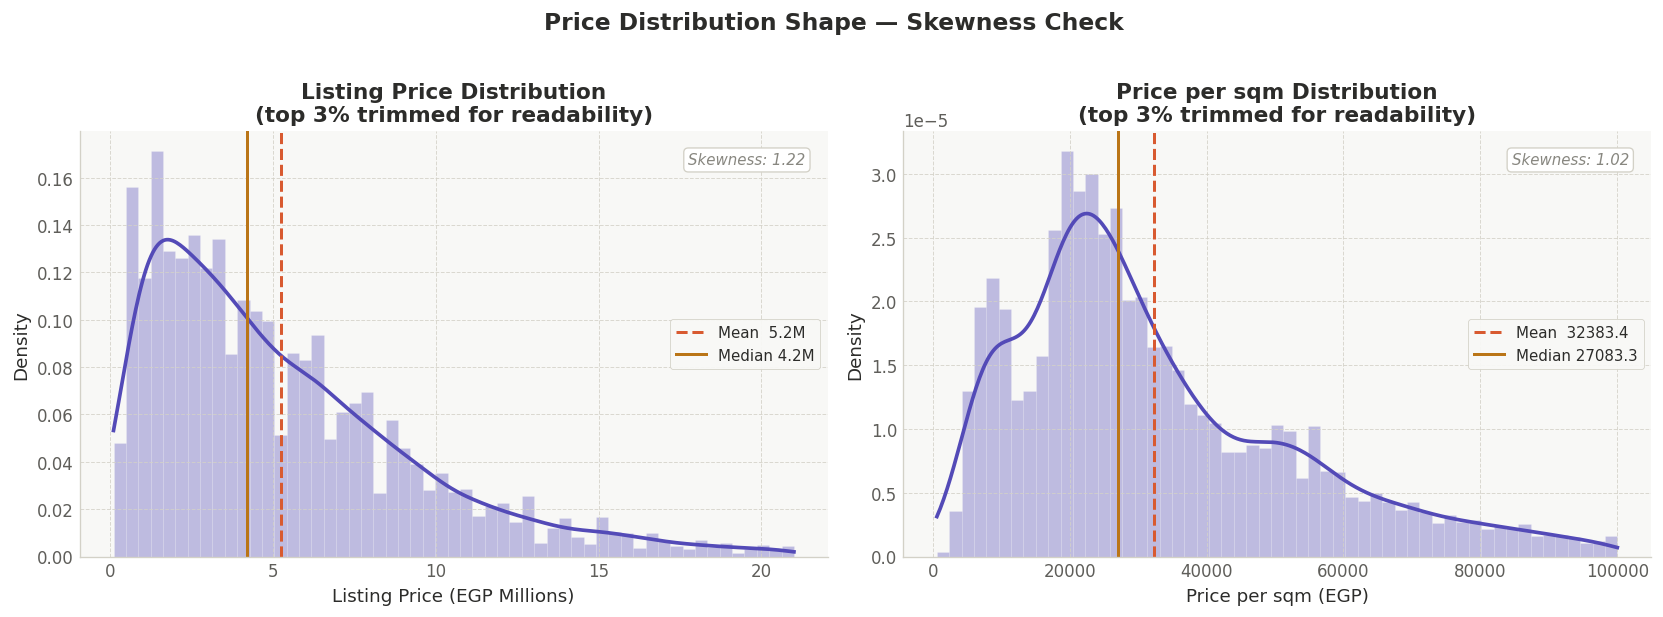

→ Saved: chart_7_Histogram_price_distribution.png


In [80]:
# CHART 7 — Price Distribution (Histogram + KDE)
# Before any analysis, always verify the shape of your target variable.
# Real estate prices are almost always right-skewed — a few luxury properties pull the mean far above the median. This chart proves and justifies using MEDIAN (not mean) everywhere else.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label, divisor) in zip(axes, [
    ('unified_price',  'Listing Price (EGP Millions)', 1e6),
    ('price_per_sqm',  'Price per sqm (EGP)',          1),
]):
    data   = df[col].dropna() / divisor
    cap    = data.quantile(0.97)        # trim top 3% so the shape is visible
    clipped = data[data <= cap]

    # Histogram
    ax.hist(clipped, bins=55, color=ACCENT, alpha=0.35,
            edgecolor='white', linewidth=0.3, density=True)

    # KDE curve (Kernel Density Estimation Curve)
    kde    = gaussian_kde(clipped, bw_method=0.18)
    x_pts  = np.linspace(clipped.min(), clipped.max(), 400)
    ax.plot(x_pts, kde(x_pts), color=ACCENT, lw=2.2)

    # Mean & Median reference lines
    mean_v   = clipped.mean()
    median_v = clipped.median()
    ax.axvline(mean_v,   color=WARM, lw=1.8, ls='--',
               label=f'Mean  {mean_v:.1f}{"M" if divisor==1e6 else ""}')
    ax.axvline(median_v, color=GOLD, lw=1.8, ls='-',
               label=f'Median {median_v:.1f}{"M" if divisor==1e6 else ""}')

    # Skewness annotation
    from scipy.stats import skew
    sk = skew(clipped)
    ax.text(0.97, 0.95, f'Skewness: {sk:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=NEUTRAL, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#D3D1C7', linewidth=0.8))

    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.set_title(f'{label.split("(")[0].strip()} Distribution\n'
                 f'(top 3% trimmed for readability)')

plt.suptitle('Price Distribution Shape — Skewness Check',
             fontsize=14, fontweight='semibold', y=1.02)
plt.tight_layout()
plt.savefig('./Plots/chart_7_Histogram_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_7_Histogram_price_distribution.png")

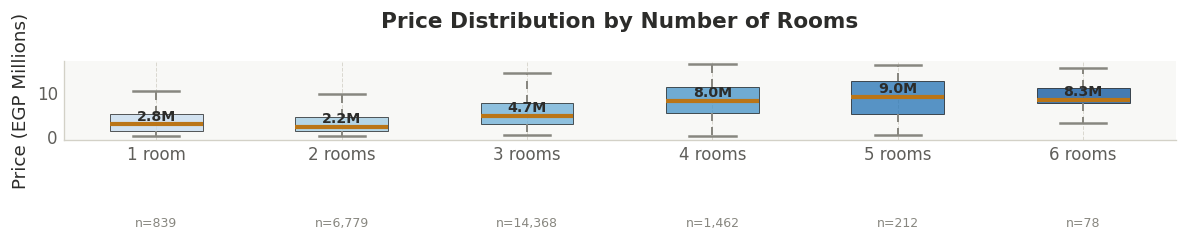

→ Saved: chart_8_BoxPlot_price_by_rooms.png


In [81]:
# CHART 8 — Price by Number of Rooms (Box Plot)
# Rooms is the most common buyer filter. This answers "how much more does each extra room actually cost?"
# A key input for the fair market value calculation and for justifying your median price benchmarks.

room_data = df[['unified_rooms','unified_price']].dropna().copy()
room_data['price_M'] = room_data['unified_price'] / 1e6

# Keep only realistic room counts (1–6) with enough samples
room_counts = room_data['unified_rooms'].value_counts()
valid_rooms = sorted([r for r in room_counts[room_counts >= 15].index
                      if 1 <= r <= 6])
room_data = room_data[room_data['unified_rooms'].isin(valid_rooms)]

cap = room_data['price_M'].quantile(0.95)
room_data = room_data[room_data['price_M'] <= cap]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    [room_data.loc[room_data['unified_rooms']==r, 'price_M']
     for r in valid_rooms],
    labels   = [f'{int(r)} room{"s" if r>1 else ""}' for r in valid_rooms],
    patch_artist = True,
    showfliers   = False,
    medianprops  = dict(color=GOLD, lw=2.5),
    whiskerprops = dict(color=NEUTRAL, lw=1.2, linestyle=(0,(4,3))),
    capprops     = dict(color=NEUTRAL, lw=1.5),
    boxprops     = dict(linewidth=0.5),
)

# Colour each box by room count (light → dark indigo)
cmap = plt.cm.get_cmap('Blues', len(valid_rooms) + 3)
for patch, k in zip(bp['boxes'], range(len(valid_rooms))):
    patch.set_facecolor(cmap(k + 2))
    patch.set_alpha(0.75)

# Median value label on each box
for k, r in enumerate(valid_rooms):
    med = room_data.loc[room_data['unified_rooms']==r, 'price_M'].median()
    ax.text(k + 1, med + cap * 0.015, f'{med:.1f}M',
            ha='center', va='bottom', fontsize=8.5,
            color='#2C2C2A', fontweight='semibold')

    # Sample size below x-axis label
    n = (room_data['unified_rooms'] == r).sum()
    ax.text(k + 1, -cap * 0.06, f'n={n:,}',
            ha='center', va='top', fontsize=7.5, color=NEUTRAL,
            transform=ax.get_xaxis_transform())

ax.set_ylabel('Price (EGP Millions)')
ax.set_title('Price Distribution by Number of Rooms\n')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('./Plots/chart_8_BoxPlot_price_by_rooms.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_8_BoxPlot_price_by_rooms.png")

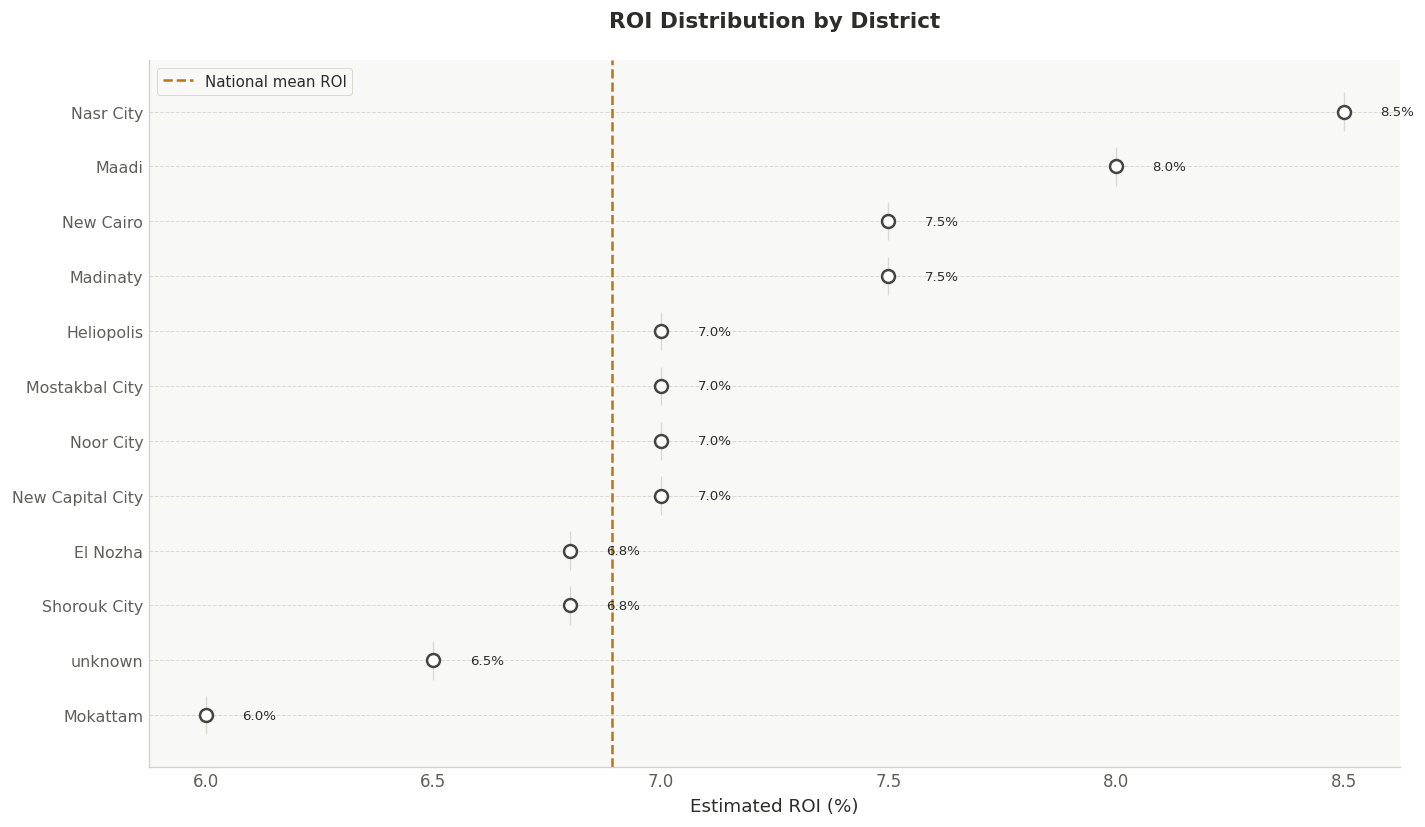

→ Saved: chart_9_Violin_roi_by_district.png


In [82]:
# CHART 9 — ROI Distribution by District (Horizontal Violin)
# Two districts can have the same mean ROI but completely different risk profiles
# one consistent, one all-over-the-place. The violin shape reveals that. Wide violin = high variance = riskier investment.
# This is the key "risk vs return" chart for your investor audience.
roi_data = df[['district','estimated_roi_percent']].dropna()

# Keep top districts by listing count, cap outliers
top_d = (district_stats.nlargest(12, 'count')['district'].tolist())
roi_sub = roi_data[roi_data['district'].isin(top_d)].copy()
roi_cap = roi_sub['estimated_roi_percent'].quantile(0.97)
roi_sub = roi_sub[roi_sub['estimated_roi_percent'] <= roi_cap]

# Sort districts by median ROI
order = (roi_sub.groupby('district')['estimated_roi_percent']
         .median().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(12, 7))

# Color each violin by its median ROI (teal = high, coral = low)
medians = roi_sub.groupby('district')['estimated_roi_percent'].median()
roi_min, roi_max = medians.min(), medians.max()

parts = ax.violinplot(
    [roi_sub.loc[roi_sub['district']==d, 'estimated_roi_percent']
     for d in order],
    positions  = range(len(order)),
    vert       = False,
    widths     = 0.7,
    showmedians= False,
    showextrema= False,
)

cmap_roi = plt.cm.get_cmap('RdYlGn', len(order))
for k, (pc, d) in enumerate(zip(parts['bodies'], order)):
    norm_val = (medians[d] - roi_min) / (roi_max - roi_min + 1e-9)
    pc.set_facecolor(cmap_roi(norm_val))
    pc.set_edgecolor('#D3D1C7')
    pc.set_linewidth(0.8)
    pc.set_alpha(0.80)

    # Median dot
    med = medians[d]
    ax.scatter(med, k, s=60, color='white',
               edgecolors='#444441', linewidths=1.5, zorder=5)
    ax.text(med + 0.08, k, f'{med:.1f}%',
            va='center', ha='left', fontsize=8, color='#2C2C2A')

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9.5)
ax.set_xlabel('Estimated ROI (%)')
ax.set_title('ROI Distribution by District\n')
ax.axvline(df['estimated_roi_percent'].mean(), color=GOLD, lw=1.5,
           ls='--', label=f'National mean ROI')
ax.legend(fontsize=9)
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('./Plots/chart_9_Violin_roi_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_9_Violin_roi_by_district.png")

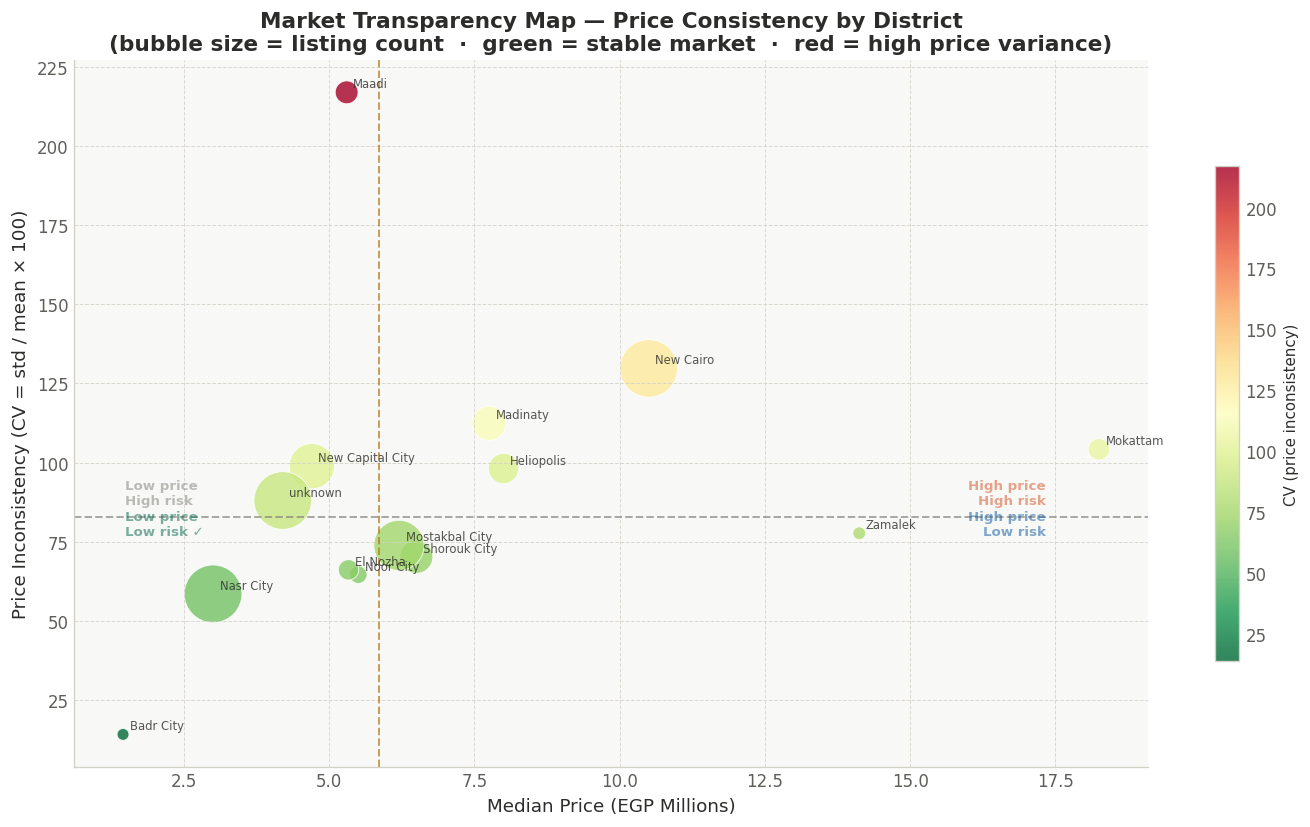

→ Saved: chart_10_RiskMap_consistency_map.png


In [83]:
# CHART 10 — Price Consistency / Risk Map (CV vs Median Price scatter)
# Coefficient of Variation (CV = std/mean) measures how inconsistent prices are in a district. High CV = unpredictable market = risky for buyers/sellers trying to price fairly.
# Low CV = stable, transparent market. This directly addresses your "Price Inconsistency" problem.
cv_data = district_stats.dropna(subset=['cv_price','median_price','count']).copy()
cv_data = cv_data[cv_data['count'] >= 10]   # only districts with enough data

# Quadrant thresholds
med_price_thresh = cv_data['median_price'].median() / 1e6
med_cv_thresh    = cv_data['cv_price'].median()

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    cv_data['median_price'] / 1e6,
    cv_data['cv_price'],
    s         = cv_data['count'].clip(upper=400) * 3,
    c         = cv_data['cv_price'],
    cmap      = 'RdYlGn_r',          # green = low risk, red = high risk
    alpha     = 0.80,
    edgecolors= 'white',
    linewidths= 0.6,
    vmin      = cv_data['cv_price'].min(),
    vmax      = cv_data['cv_price'].max(),
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('CV (price inconsistency)', fontsize=9)

# Quadrant reference lines
ax.axvline(med_price_thresh, color=GOLD,   lw=1.2, ls='--', alpha=0.7)
ax.axhline(med_cv_thresh,    color=NEUTRAL, lw=1.2, ls='--', alpha=0.7)

# Quadrant labels
quad_style = dict(fontsize=8, alpha=0.55, fontweight='semibold')
ax.text(cv_data['median_price'].max()/1e6 * 0.95, med_cv_thresh * 1.05,
        'High price\nHigh risk', ha='right', color=WARM, **quad_style)
ax.text(cv_data['median_price'].min()/1e6 * 1.02, med_cv_thresh * 0.93,
        'Low price\nLow risk ✓', ha='left', color=ACCENT2, **quad_style)
ax.text(cv_data['median_price'].max()/1e6 * 0.95, med_cv_thresh * 0.93,
        'High price\nLow risk', ha='right', color=COLD, **quad_style)
ax.text(cv_data['median_price'].min()/1e6 * 1.02, med_cv_thresh * 1.05,
        'Low price\nHigh risk', ha='left', color=NEUTRAL, **quad_style)

# Label each district bubble
for _, row in cv_data.iterrows():
    ax.annotate(row['district'],
                xy=(row['median_price']/1e6, row['cv_price']),
                xytext=(4, 3), textcoords='offset points',
                fontsize=7, color='#2C2C2A', alpha=0.8)

ax.set_xlabel('Median Price (EGP Millions)')
ax.set_ylabel('Price Inconsistency (CV = std / mean × 100)')
ax.set_title('Market Transparency Map — Price Consistency by District\n'
             '(bubble size = listing count  ·  green = stable market  ·  '
             'red = high price variance)')
ax.grid(True)
plt.tight_layout()
plt.savefig('./Plots/chart_10_RiskMap_consistency_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Saved: chart_10_RiskMap_consistency_map.png")

# ML 

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [85]:
df.head()

,source,unified_price,unified_area,price_per_sqm,unified_rooms,unified_bathrooms,unified_property_type,district,unified_location,gross_rental_yield_pct,estimated_annual_rent,estimated_roi_percent,estimated_monthly_rent,has_elevator,has_security,has_balcony,has_pool,has_garden,has_parking,median_price_per_district
0,property_finder,10850000,164,66158.536585,3,2,unknown,New Cairo,"El Patio Oro, 5th Settlement Compounds, The 5t...",7.5,813750.0,7.5,67812.500,0,0,0,0,0,0,10500000.0
1,property_finder,15272500,176,86775.568182,3,3,unknown,New Cairo,"Azzar 2, 5th Settlement Compounds, The 5th Set...",7.5,1145437.5,7.5,95453.125,0,0,0,0,0,0,10500000.0
2,property_finder,36000000,650,55384.615385,5,6,unknown,New Cairo,"Katameya Palms, 5th Settlement Compounds, The ...",7.5,2700000.0,7.5,225000.000,0,0,0,0,0,0,10500000.0
3,property_finder,3935000,158,24905.063291,3,3,unknown,New Cairo,"The Icon Residence, 5th Settlement Compounds, ...",7.5,295125.0,7.5,24593.750,0,0,0,0,0,0,10500000.0
4,property_finder,3530000,72,49027.777778,0,1,unknown,New Cairo,"Shalya Taj City, 5th Settlement Compounds, The...",7.5,264750.0,7.5,22062.500,0,0,0,0,0,0,10500000.0


### Outliers

In [86]:

for col in ['unified_rooms', 'unified_area', 'unified_bathrooms']:
    upper = df[col].quantile(0.99)
    outliers = (df[col] > upper).sum()
    print(f"\n{col}:")
    print(f"  max value       : {df[col].max():.0f}")
    print(f"  99th percentile : {upper:.0f}")
    print(f"  rows to clip    : {outliers}")
    print(f"  top 5 values    : {sorted(df[col].unique())[-5:]}")


unified_rooms:
  max value       : 230
  99th percentile : 5
  rows to clip    : 235
  top 5 values    : [np.int64(30), np.int64(32), np.int64(100), np.int64(130), np.int64(230)]

unified_area:
  max value       : 1800
  99th percentile : 488
  rows to clip    : 252
  top 5 values    : [np.int64(1600), np.int64(1650), np.int64(1700), np.int64(1750), np.int64(1800)]

unified_bathrooms:
  max value       : 170
  99th percentile : 5
  rows to clip    : 167
  top 5 values    : [np.int64(15), np.int64(20), np.int64(23), np.int64(33), np.int64(170)]


there are 230 rooms? 170 bathrooms? 1800 area? those are things we can't think are real. We have to clip 

In [87]:
for col in ['unified_rooms', 'unified_area', 'unified_bathrooms']:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

df = df.reset_index(drop=True)

### Data Leakage 

lets's first see things with high correlation with price

In [88]:
import pandas as pd
import numpy as np

corr = df.select_dtypes(include=[np.number]).corr()

# Get correlations with price, sorted by absolute value
price_corr = corr[['unified_price']].copy()
price_corr['abs_corr'] = price_corr['unified_price'].abs()
price_corr = price_corr.sort_values('abs_corr', ascending=False).drop(columns='abs_corr')

print(price_corr.to_string())

                           unified_price
unified_price                   1.000000
estimated_monthly_rent          0.996017
estimated_annual_rent           0.996017
price_per_sqm                   0.686348
unified_area                    0.606077
unified_bathrooms               0.562817
median_price_per_district       0.415359
unified_rooms                   0.402159
has_pool                       -0.100302
has_parking                    -0.088656
has_balcony                    -0.077388
has_security                   -0.067759
has_garden                     -0.039914
gross_rental_yield_pct          0.037365
estimated_roi_percent           0.037365
has_elevator                    0.020531


As we can see `estimated_monthly_rent` & `estimated_annual_rent` have high correlation with `unified_price`, me must take care to remove those before training. `price_per_sqm` is also leaky since it is computed with price, why? Let's see how many price_per_sqm are there per district, if they're a lot they may be cheating as we now have unique values for each property.

In [89]:
df.groupby('district')['price_per_sqm'].nunique()

district
Badr City             10
El Manial              2
El Nozha              48
Garden City            3
Heliopolis           108
Maadi                 58
Madinaty             131
Mokattam              55
Mostakbal City       273
Nasr City            903
New Cairo           1688
New Capital City     224
Noor City             37
Shorouk City         127
Zamalek               18
unknown             4962
Name: price_per_sqm, dtype: int64

Now let's drop leaky cols, also suspect that `unified_property_type` isn't filled properly because most of them are unknown.

In [90]:
print("=" * 50)
print("FEATURE AUDIT: unified_property_type")
print("=" * 50)
print(df['unified_property_type'].value_counts())
print(f"\n{df['unified_property_type'].nunique()} unique values")


FEATURE AUDIT: unified_property_type
unified_property_type
unknown      25164
Townhouse        1
Name: count, dtype: int64

2 unique values


Yeah only 1 has data which is townhouse, we'll drop this too

In [91]:
leaky_cols = [
    'estimated_monthly_rent',
    'estimated_annual_rent',
    'gross_rental_yield_pct',
    'estimated_roi_percent',
    'price_per_sqm',
    'median_price_per_district',
    'unified_location',
]

X = df.drop(columns=leaky_cols + ['unified_property_type']+['unified_price'])
y = df['unified_price']

In [92]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

let's make the training & test split

### Feature Engineering

Let's now target-encode median price since we removed `price_per_sqm`, this will be important for prediction as we need info about location to be meaningful and not burden our model to learn all of this.

In [93]:
# Reset indices
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

ppsm_series = y_train / X_train['unified_area']
print("NaNs in ppsm_series:", np.isnan(ppsm_series).sum())
print("Sample values:", ppsm_series[:5])

district_ppsm = ppsm_series.groupby(X_train['district']).median()

X_train['district_ppsm'] = X_train['district'].map(district_ppsm)
X_test['district_ppsm']  = X_test['district'].map(district_ppsm)

overall_ppsm = ppsm_series.median()
X_train['district_ppsm'] = X_train['district_ppsm'].fillna(overall_ppsm)
X_test['district_ppsm']  = X_test['district_ppsm'].fillna(overall_ppsm)

NaNs in ppsm_series: 0
Sample values: 0    22222.222222
1    58000.000000
2    21000.000000
3    22222.222222
4    15555.555556
dtype: float64


Now let's remove the old categorical data `district` & `unified_property_type`

In [94]:
X_train = X_train.drop(columns=['district', 'source'])
X_test  = X_test.drop(columns=['district', 'source'])

Now let's one-hot encode the categorical columns

In [95]:
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

Let's log transform target to handle skewed price better

In [96]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

Let's scale our input data first so that it's easier for the model to learn.

In [97]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## Linear Regression

Now let's train our model.

In [98]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Let's evaluate our model

In [99]:
y_pred_lr_log = lr_model.predict(X_test_scaled)
y_pred_lr    = np.expm1(y_pred_lr_log)

mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:>15,.0f} EGP")
print(f"RMSE : {rmse:>15,.0f} EGP")
print(f"R²   : {r2:.4f}")



MAE  :       2,807,612 EGP
RMSE :       5,956,745 EGP
R²   : 0.5165


The model is doing well but the shift from median is a bit big. We can try random forests.

## Random Forests

Let's import it first from sklearn

In [100]:
from sklearn.ensemble import RandomForestRegressor

In [101]:
rf_model = RandomForestRegressor(
    n_estimators=300, # 300 trees
    max_depth= 20, # deeper trees
    random_state=42,
    n_jobs=-1        
)
rf_model.fit(X_train, y_train)  # no scaling needed for tree models

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

The good thing about sklearn is its ease to train and try experiments.

In [102]:
y_pred_rf = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae:>15,.0f} EGP")
print(f"RMSE : {rmse:>15,.0f} EGP")
print(f"R²   : {r2:.4f}")

MAE  :       2,269,578 EGP
RMSE :       5,429,813 EGP
R²   : 0.5982


## The district problem.

The problem is in `district`, let's see how much of it is unknown.

In [103]:
# Train separate models
mask_known = df['district'] != 'unknown'

df_known   = df[mask_known].reset_index(drop=True)
df_unknown = df[~mask_known].reset_index(drop=True)

print(f"Known   : {len(df_known)} rows")
print(f"Unknown : {len(df_unknown)} rows")

Known   : 6920 rows
Unknown : 18245 rows


We have 18,000+ properties without known district

We also have `unified_location` which can help us

In [104]:
print(df['unified_location'].head(10))

0    El Patio Oro, 5th Settlement Compounds, The 5t...
1    Azzar 2, 5th Settlement Compounds, The 5th Set...
2    Katameya Palms, 5th Settlement Compounds, The ...
3    The Icon Residence, 5th Settlement Compounds, ...
4    Shalya Taj City, 5th Settlement Compounds, The...
5    American University Housing District, 5th Sett...
6    Talala, New Heliopolis Compounds, New Heliopol...
7    Elm Tree Park, Sarai, Mostakbal City Compounds...
8    Elan Sarai, Sarai, Mostakbal City Compounds, M...
9    De Joya, New Capital Compounds, New Capital Ci...
Name: unified_location, dtype: str


from here we can see that the last thing in `unified_location` is our distriict.

In [105]:
# Extract last segment as district
print(df['unified_location'].str.split(',').str[-2].str.strip())

0        New Cairo City
1        New Cairo City
2        New Cairo City
3        New Cairo City
4        New Cairo City
              ...      
25160               NaN
25161               NaN
25162               NaN
25163               NaN
25164               NaN
Name: unified_location, Length: 25165, dtype: object


In [106]:
df['extracted_district'] = df['unified_location'].str.split(',').str[-2].str.strip()

print(df['extracted_district'].value_counts().head(20))
print("\nNaNs:", df['extracted_district'].isna().sum())
print("Unique values:", df['extracted_district'].nunique())

extracted_district
Nasr City                       3567
New Cairo City                  2172
Mostakbal City - Future City     303
New Capital City                 247
Madinaty                         140
Shorouk City                     130
New Heliopolis                    77
Hay El Maadi                      60
Mokattam                          54
El Nozha                          52
Noor City                         37
Heliopolis - Masr El Gedida       22
Zamalek                           20
Badr City                         17
Ring Road                         10
Hay Masr El Kadima                 3
Garden City                        3
El Khalifa                         2
Cairo - Ismailia Desert Road       2
Hay El Manial                      2
Name: count, dtype: int64

NaNs: 18245
Unique values: 20


No also 18,000+ nans, so we still have the same problem, maybe we can train on only the 7k with data about distruict.

## Retraining on Known Districts

In [107]:
df_model = df[df['district'] != 'unknown'].reset_index(drop=True)
print(f"Training on {len(df_model)} rows with known districts")

Training on 6920 rows with known districts


In [108]:
df_model.head()

,source,unified_price,unified_area,price_per_sqm,unified_rooms,unified_bathrooms,unified_property_type,district,unified_location,gross_rental_yield_pct,...,estimated_roi_percent,estimated_monthly_rent,has_elevator,has_security,has_balcony,has_pool,has_garden,has_parking,median_price_per_district,extracted_district
0,property_finder,10850000,164.00,66158.536585,3,2,unknown,New Cairo,"El Patio Oro, 5th Settlement Compounds, The 5t...",7.5,...,7.5,67812.500,0,0,0,0,0,0,10500000.0,New Cairo City
1,property_finder,15272500,176.00,86775.568182,3,3,unknown,New Cairo,"Azzar 2, 5th Settlement Compounds, The 5th Set...",7.5,...,7.5,95453.125,0,0,0,0,0,0,10500000.0,New Cairo City
2,property_finder,36000000,488.08,55384.615385,5,5,unknown,New Cairo,"Katameya Palms, 5th Settlement Compounds, The ...",7.5,...,7.5,225000.000,0,0,0,0,0,0,10500000.0,New Cairo City
3,property_finder,3935000,158.00,24905.063291,3,3,unknown,New Cairo,"The Icon Residence, 5th Settlement Compounds, ...",7.5,...,7.5,24593.750,0,0,0,0,0,0,10500000.0,New Cairo City
4,property_finder,3530000,72.00,49027.777778,0,1,unknown,New Cairo,"Shalya Taj City, 5th Settlement Compounds, The...",7.5,...,7.5,22062.500,0,0,0,0,0,0,10500000.0,New Cairo City


let's make the above cleaning pipeline in one pass.

In [109]:

X = df_model.drop(columns=leaky_cols+ ['source'] + ['unified_property_type'] + ['unified_price'])
y = df_model['unified_price']

print(f"\nFinal shape: {X.shape}")
print(f"Features   : {X.columns.tolist()}")


Final shape: (6920, 11)
Features   : ['unified_area', 'unified_rooms', 'unified_bathrooms', 'district', 'has_elevator', 'has_security', 'has_balcony', 'has_pool', 'has_garden', 'has_parking', 'extracted_district']


In [110]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_new = X_train_new.reset_index(drop=True)
X_test_new  = X_test_new.reset_index(drop=True)
y_train_new = y_train_new.reset_index(drop=True)
y_test_new  = y_test_new.reset_index(drop=True)

# ──  Target encode district ─────────────────────────────────────────────────
ppsm_series   = y_train_new / X_train_new['unified_area']
district_ppsm = ppsm_series.groupby(X_train_new['district']).median()
overall_ppsm  = ppsm_series.median()

X_train_new['district_ppsm'] = X_train_new['district'].map(district_ppsm).fillna(overall_ppsm)
X_test_new['district_ppsm']  = X_test_new['district'].map(district_ppsm).fillna(overall_ppsm)

X_train_new = X_train_new.drop(columns=['district','extracted_district'])
X_test_new  = X_test_new.drop(columns=['district','extracted_district'])


train on the random forest again.

In [111]:
rf_model.fit(X_train_new, y_train_new)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Let's see if model performs better.

In [112]:
y_pred_new = rf_model.predict(X_test_new)

mae  = mean_absolute_error(y_test_new, y_pred_new)
rmse = np.sqrt(mean_squared_error(y_test_new, y_pred_new))
r2   = r2_score(y_test_new, y_pred_new)

print(f"MAE  : {mae:>15,.0f} EGP")
print(f"RMSE : {rmse:>15,.0f} EGP")
print(f"R²   : {r2:.4f}")

MAE  :       3,455,077 EGP
RMSE :       9,283,225 EGP
R²   : 0.6701


Model performed worse, because we have less data.

In [113]:
importance_df = pd.DataFrame({
    'feature'   : X_train_new.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

          feature  importance
     unified_area    0.773471
    district_ppsm    0.095982
unified_bathrooms    0.079397
    unified_rooms    0.045535
         has_pool    0.003986
      has_balcony    0.000855
     has_security    0.000410
      has_parking    0.000266
       has_garden    0.000097
     has_elevator    0.000000


## Trying XGBoost

In [114]:
from xgboost import XGBRegressor
## instantiate our model
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

training the model, we'll use all districts not the dropped rows one

In [115]:
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)


[0]	validation_0-rmse:8284100.99949
[1]	validation_0-rmse:8020030.74193
[2]	validation_0-rmse:7780204.57353
[3]	validation_0-rmse:7557191.34166
[4]	validation_0-rmse:7371995.75092
[5]	validation_0-rmse:7171928.58045
[6]	validation_0-rmse:6989232.57423
[7]	validation_0-rmse:6848197.00145
[8]	validation_0-rmse:6695136.37774
[9]	validation_0-rmse:6557841.09975
[10]	validation_0-rmse:6437109.64586
[11]	validation_0-rmse:6353887.26227
[12]	validation_0-rmse:6272119.45921
[13]	validation_0-rmse:6187051.56060
[14]	validation_0-rmse:6090312.78652
[15]	validation_0-rmse:6008854.47342
[16]	validation_0-rmse:5929021.26704
[17]	validation_0-rmse:5852411.77693
[18]	validation_0-rmse:5791637.77120
[19]	validation_0-rmse:5737512.81937
[20]	validation_0-rmse:5688471.67843
[21]	validation_0-rmse:5640108.77390
[22]	validation_0-rmse:5610532.37802
[23]	validation_0-rmse:5569987.19221
[24]	validation_0-rmse:5533115.75205
[25]	validation_0-rmse:5505872.68726
[26]	validation_0-rmse:5477262.29184
[27]	valida

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

let's see how good it performed

In [116]:
y_pred_xgb = xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2   = r2_score(y_test, y_pred_xgb)

print(f"MAE  : {mae:>15,.0f} EGP")
print(f"RMSE : {rmse:>15,.0f} EGP")
print(f"R²   : {r2:.4f}")

MAE  :       2,379,064 EGP
RMSE :       5,485,644 EGP
R²   : 0.5899


Now we know the data is the bottleneck not the algorithm. Our problem isn't trying or finetuning algos, it can only be solved by trying to extract data about districts.

## Ensemble model of known and unknown districts

Now we'll try our best to mitigate this problem using an ensemble model. one will have the encoding of `district_ppsm`, price per sqm for district, and one will only have size data. On inference time we'll see if the property is known or unknown and see which model to use.

In [117]:
mask_known = df['district'] != 'unknown'

df_known   = df[mask_known].reset_index(drop=True)
df_unknown = df[~mask_known].reset_index(drop=True)

print(f"Known   : {len(df_known)} rows")
print(f"Unknown : {len(df_unknown)} rows")

Known   : 6920 rows
Unknown : 18245 rows


### Known Model

In [118]:
X_known = df_known.drop(columns=leaky_cols + ['source'] + ['unified_property_type'] + ['extracted_district']+ ['unified_price'])
y_known = df_known['unified_price']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42
)
X_train_k = X_train_k.reset_index(drop=True)
X_test_k  = X_test_k.reset_index(drop=True)
y_train_k = y_train_k.reset_index(drop=True)
y_test_k  = y_test_k.reset_index(drop=True)

# Target encode district
ppsm_k        = y_train_k / X_train_k['unified_area']
district_ppsm = ppsm_k.groupby(X_train_k['district']).median()
overall_ppsm  = ppsm_k.median()

X_train_k['district_ppsm'] = X_train_k['district'].map(district_ppsm).fillna(overall_ppsm)
X_test_k['district_ppsm']  = X_test_k['district'].map(district_ppsm).fillna(overall_ppsm)
# X_train_k = X_train_k.drop(columns=['district'])
# X_test_k  = X_test_k.drop(columns=['district'])


In [119]:
district_count = X_train_k['district'].value_counts()
print(district_count)
X_train_k['district_count'] = X_train_k['district'].map(district_count)
X_test_k['district_count']  = X_test_k['district'].map(district_count).fillna(0)

district
Nasr City           2884
New Cairo           1725
Mostakbal City       245
New Capital City     193
Shorouk City         109
Madinaty             105
Heliopolis            84
Maadi                 51
Mokattam              44
El Nozha              39
Noor City             27
Zamalek               15
Badr City             10
Garden City            3
El Manial              2
Name: count, dtype: int64


While keeping the district value is nice, we still have categories with very few samples like "Graden City", "Manial"

In [120]:
# One-hot encode
X_train_k = pd.get_dummies(X_train_k, columns=['district'], dummy_na=False)
X_test_k  = pd.get_dummies(X_test_k,  columns=['district'], dummy_na=False)

# Align columns
X_train_k, X_test_k = X_train_k.align(X_test_k, join='left', axis=1, fill_value=0)

In [121]:
model_known = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model_known.fit(X_train_k, y_train_k)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [122]:
y_pred_k = model_known.predict(X_test_k)
print("KNOWN DISTRICTS MODEL")
print(f"MAE  : {mean_absolute_error(y_test_k, y_pred_k):>15,.0f} EGP")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_k, y_pred_k)):>15,.0f} EGP")
print(f"R²   : {r2_score(y_test_k, y_pred_k):.4f}")


KNOWN DISTRICTS MODEL
MAE  :       3,447,978 EGP
RMSE :       9,116,519 EGP
R²   : 0.6818


Our known districts model is now trained

### Unknown Model

In [123]:
X_unknown = df_unknown.drop(columns=leaky_cols + ['unified_price','source','unified_property_type','extracted_district', 'district'])
y_unknown = df_unknown['unified_price']

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unknown, y_unknown, test_size=0.2, random_state=42
)
X_train_u = X_train_u.reset_index(drop=True)
X_test_u  = X_test_u.reset_index(drop=True)
y_train_u = y_train_u.reset_index(drop=True)
y_test_u  = y_test_u.reset_index(drop=True)

In [124]:
X_train_u.dtypes

unified_area         float64
unified_rooms          int64
unified_bathrooms      int64
has_elevator           int64
has_security           int64
has_balcony            int64
has_pool               int64
has_garden             int64
has_parking            int64
dtype: object

In [125]:
model_unknown = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model_unknown.fit(X_train_u, y_train_u)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [126]:
y_pred_u = model_unknown.predict(X_test_u)
print("UNKNOWN DISTRICTS MODEL")

print(f"MAE  : {mean_absolute_error(y_test_u, y_pred_u):>15,.0f} EGP")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_u, y_pred_u)):>15,.0f} EGP")
print(f"R²   : {r2_score(y_test_u, y_pred_u):.4f}")

UNKNOWN DISTRICTS MODEL
MAE  :       2,023,561 EGP
RMSE :       3,575,380 EGP
R²   : 0.4898


This model is doing well as it has more data points

### Ensembling

In [127]:
y_test_all = pd.concat([y_test_k, y_test_u]).reset_index(drop=True)
y_pred_all = np.concatenate([y_pred_k, y_pred_u])


print("COMBINED (ENSEMBLE)")

print(f"MAE  : {mean_absolute_error(y_test_all, y_pred_all):>15,.0f} EGP")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_all, y_pred_all)):>15,.0f} EGP")
print(f"R²   : {r2_score(y_test_all, y_pred_all):.4f}")

COMBINED (ENSEMBLE)
MAE  :       2,415,254 EGP
RMSE :       5,667,661 EGP
R²   : 0.6574


Not much better but at least we tried!

## Plots

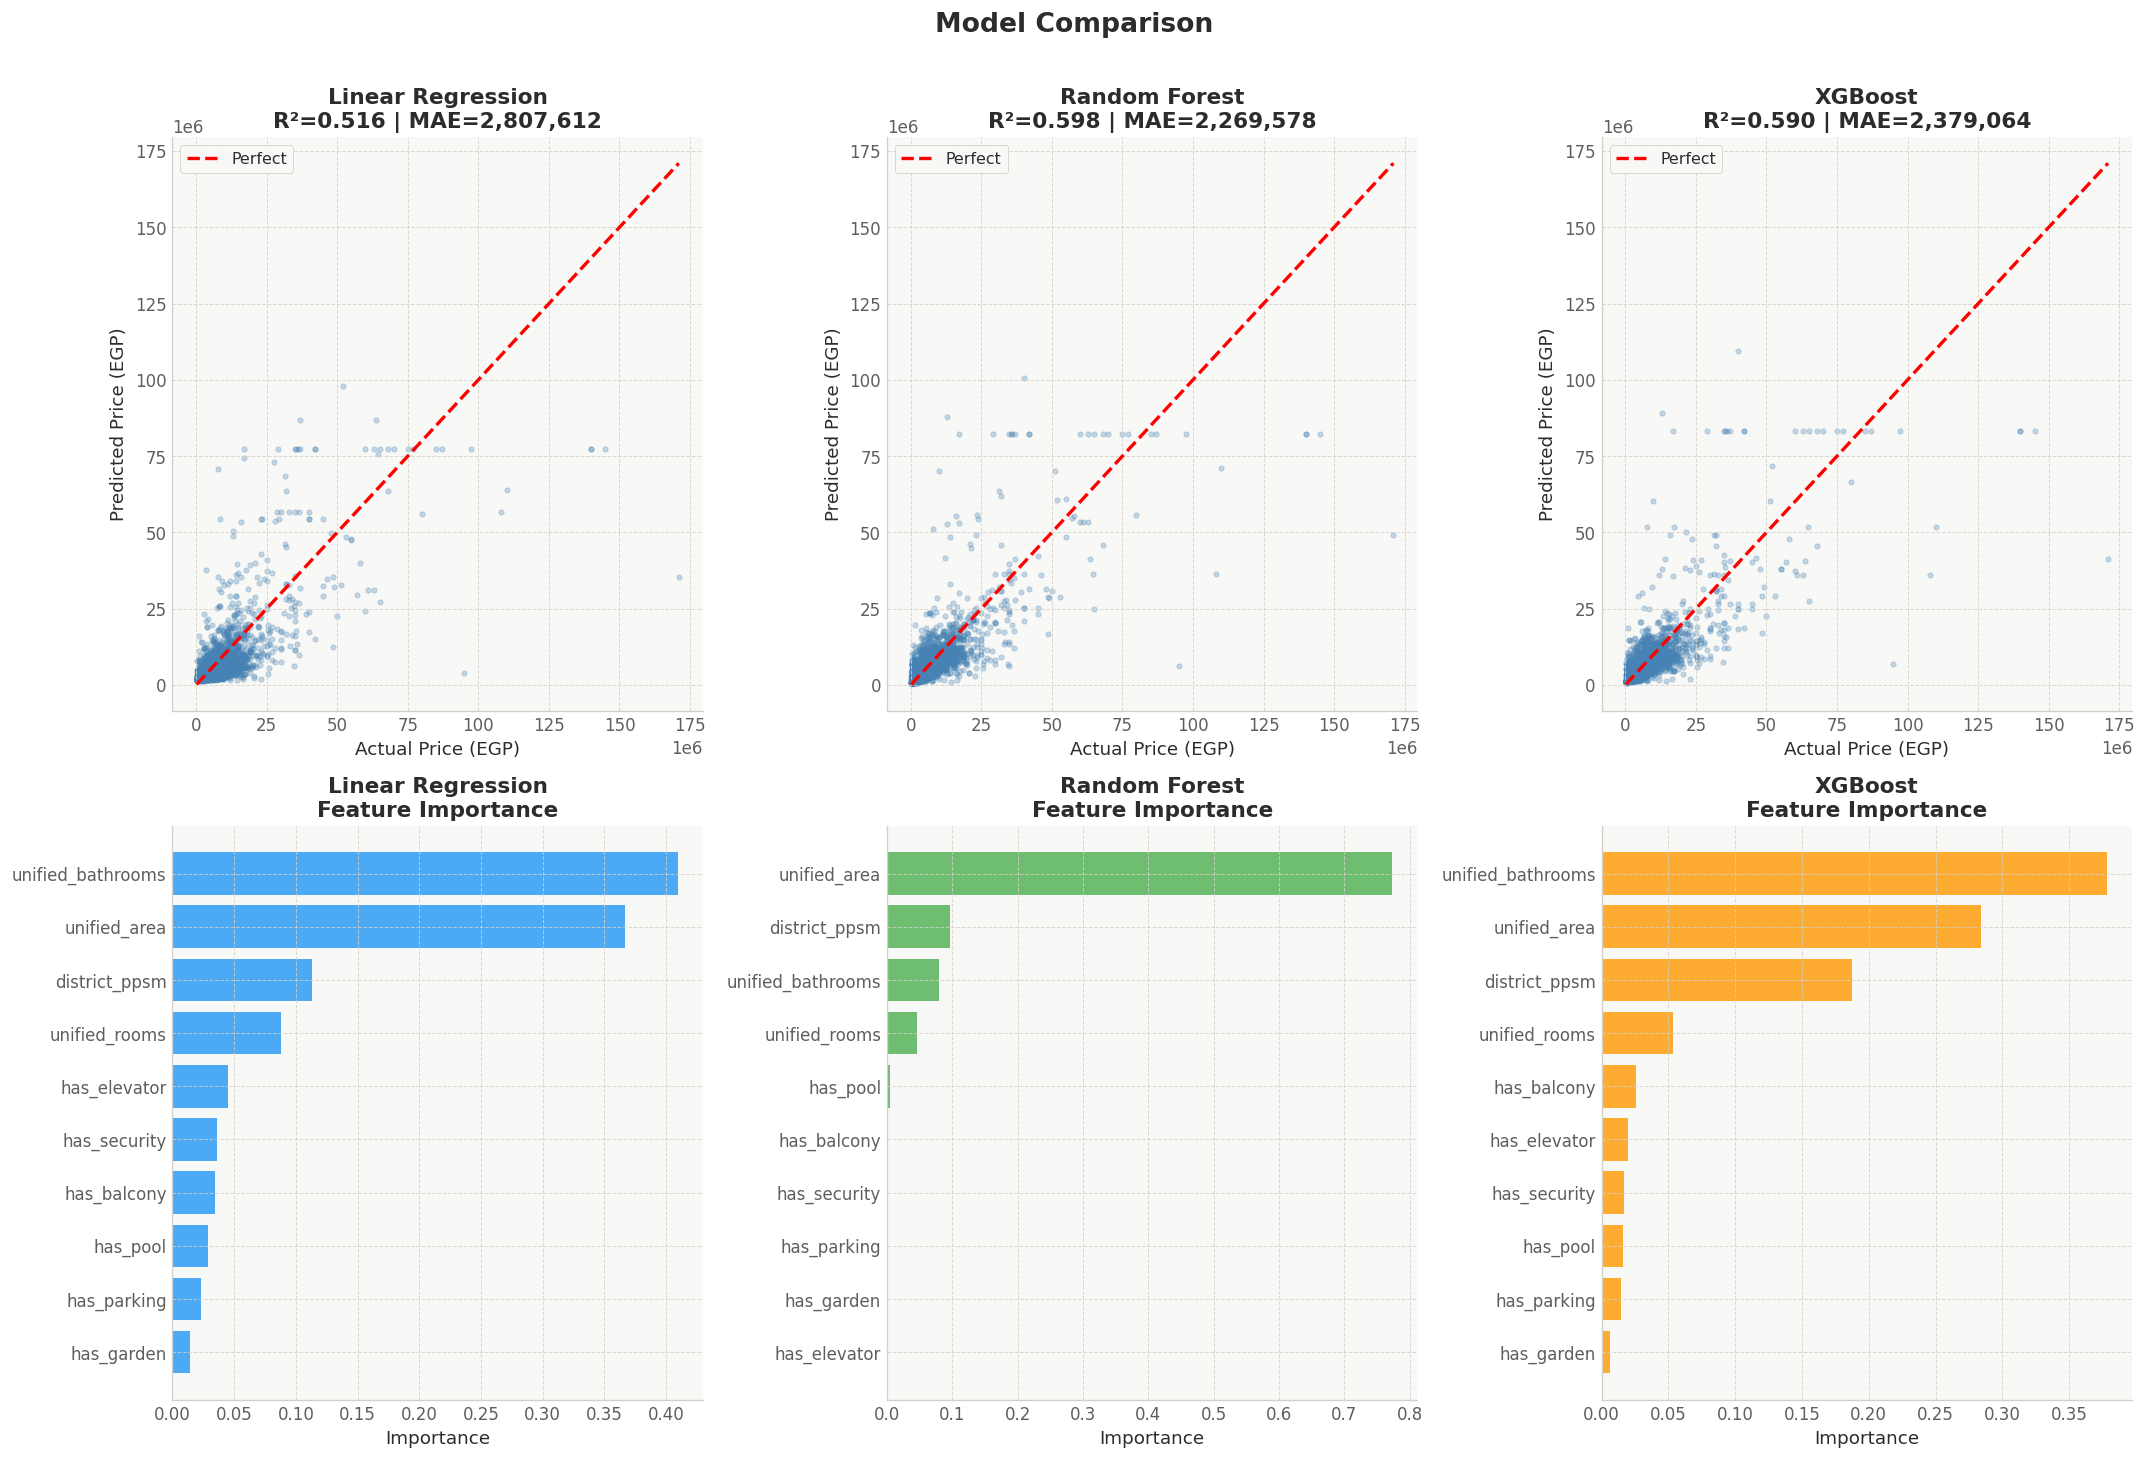

In [128]:
import matplotlib.pyplot as plt
import numpy as np

# ── Assume you have these from your three models ──────────────────────────────
# y_pred_lr  — linear regression predictions
# y_pred_rf  — random forest predictions  
# y_pred_xgb — xgboost predictions

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold', y=1.01)

models = {
    'Linear Regression': y_pred_lr,
    'Random Forest'    : y_pred_rf,
    'XGBoost'          : y_pred_xgb,
}

# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
for ax, (name, y_pred) in zip(axes[0], models.items()):
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')

    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')

    ax.set_xlabel('Actual Price (EGP)')
    ax.set_ylabel('Predicted Price (EGP)')
    ax.set_title(f'{name}\nR²={r2:.3f} | MAE={mae:,.0f}')
    ax.legend()
    ax.ticklabel_format(style='sci', axis='both', scilimits=(6,6))

# ── 2. Feature Importance ─────────────────────────────────────────────────────
feature_names = X_train.columns.tolist()

# Linear regression — use absolute coefficients (need scaler for this)
lr_importance = pd.Series(np.abs(lr_model.coef_), index=feature_names).sort_values(ascending=True)

# Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)

# XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)

importances = {
    'Linear Regression': lr_importance,
    'Random Forest'    : rf_importance,
    'XGBoost'          : xgb_importance,
}

colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, (name, imp), color in zip(axes[1], importances.items(), colors):
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}\nFeature Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./Plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

These graphs are really telling, and is making me a little bit suspicious, it's weird for me that unified bathrooms should matter that much.

In [129]:
# 1. Check correlation between bathrooms and area
print(df[['unified_bathrooms', 'unified_area', 'unified_price']].corr())


                   unified_bathrooms  unified_area  unified_price
unified_bathrooms           1.000000      0.717856       0.562817
unified_area                0.717856      1.000000       0.606077
unified_price               0.562817      0.606077       1.000000


Yes there is high correlation with area.

In [130]:
# Train without bathrooms
X_no_bath = X_train.drop(columns=['unified_bathrooms'])
rf_test = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_test.fit(X_no_bath, y_train)
y_pred_test = rf_test.predict(X_test.drop(columns=['unified_bathrooms']))
print(f"R² without bathrooms: {r2_score(y_test, y_pred_test):.4f}")
print(f"R² with bathrooms   : {r2_score(y_test, y_pred_rf):.4f}")

R² without bathrooms: 0.5749
R² with bathrooms   : 0.5982


Yeah apparently it would matter that much.

In [131]:
import pickle

# Save model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save the district_ppsm mapping too — you need it to encode new data at prediction time
with open('district_ppsm.pkl', 'wb') as f:
    pickle.dump(district_ppsm, f)

print("✓ Model saved: rf_model.pkl")
print("✓ Encoding saved: district_ppsm.pkl")

✓ Model saved: rf_model.pkl
✓ Encoding saved: district_ppsm.pkl
